# Thực hành Buổi 08: Descriptive Analytics & Báo cáo KPI Doanh nghiệp

**Khóa đào tạo:** Phân tích Dữ liệu Lớn (Big Data Analysis)

**Công cụ:** Pandas, Matplotlib, Seaborn

**Đầu vào ➔ Đầu ra:** dataset giao dịch sạch của Bài 6 ➔ Báo cáo KPI & notebook phân tích mô tả

> **Chuỗi bài 06–09** là một pipeline liên tục: Bài 6 làm sạch ➔ Bài 7 tạo đặc trưng ➔ Bài 8 báo cáo KPI ➔ Bài 9 chẩn đoán & phát hiện bất thường. Chạy các cell theo đúng thứ tự từ trên xuống.
> ⚠️ **Điều kiện tiên quyết:** chạy xong `lab6/Lab6.ipynb` trước — buổi này đọc `data/processed/enterprise_transactions_clean.parquet` và `data/raw/customer_churn.csv` do Bài 6 sinh ra.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 100
pd.options.display.float_format = "{:,.2f}".format

RAW = Path("../data/raw"); RAW.mkdir(parents=True, exist_ok=True)
PROCESSED = Path("../data/processed"); PROCESSED.mkdir(parents=True, exist_ok=True)
print("pandas", pd.__version__, "| numpy", np.__version__)

pandas 3.0.5 | numpy 2.5.0


# BÀI 8 — DESCRIPTIVE ANALYTICS & BÁO CÁO KPI DOANH NGHIỆP

**Mục tiêu:** trả lời câu hỏi *"Chuyện gì đã xảy ra?"* bằng thống kê mô tả + bộ KPI kinh doanh + biểu đồ Matplotlib/Seaborn.

| KPI | Công thức |
|:---|:---|
| Doanh thu thuần | Σ `amount` của giao dịch `HOAN_TAT` |
| Chi phí | Σ `cost` của giao dịch `HOAN_TAT` |
| Lợi nhuận gộp / Biên LN gộp | Doanh thu − Chi phí; (LN gộp ÷ Doanh thu) |
| AOV (giá trị đơn trung bình) | Doanh thu ÷ số giao dịch |
| Tỷ lệ hoàn trả | số giao dịch `HOAN_TRA` ÷ tổng giao dịch |
| Tỷ lệ rời bỏ (churn rate) | số KH `churn=1` ÷ tổng số KH |

## 8.1. Thống kê mô tả

In [2]:
tx = pd.read_parquet(PROCESSED / "enterprise_transactions_clean.parquet")
tx["thang"] = tx["ts"].dt.to_period("M").astype(str)
tx_ht = tx[tx["status"] == "HOAN_TAT"]

print(tx_ht["amount"].describe().to_frame("amount").T.to_string())
print(f"\nSkewness (độ lệch)  : {tx_ht['amount'].skew():.2f}  (>1: lệch phải nặng)")
print(f"Kurtosis (độ nhọn)  : {tx_ht['amount'].kurtosis():.1f}  (đuôi rất dày — dấu vết outlier)")
print(f"Trung vị {tx_ht['amount'].median():,.0f} đ << Trung bình {tx_ht['amount'].mean():,.0f} đ"
      "  ->  báo cáo giá trị 'điển hình' nên dùng TRUNG VỊ")

           count         mean          std        min        25%        50%          75%           max
amount 57,882.00 1,044,464.44 1,364,090.87 107,950.00 295,200.00 721,000.00 1,222,275.00 23,844,189.00

Skewness (độ lệch)  : 5.97  (>1: lệch phải nặng)
Kurtosis (độ nhọn)  : 61.3  (đuôi rất dày — dấu vết outlier)
Trung vị 721,000 đ << Trung bình 1,044,464 đ  ->  báo cáo giá trị 'điển hình' nên dùng TRUNG VỊ


## 8.2. Bảng KPI toàn kỳ

In [3]:
kh = pd.read_csv(RAW / "customer_churn.csv")

doanh_thu = tx_ht["amount"].sum()
chi_phi = tx_ht["cost"].sum()
ln_gop = doanh_thu - chi_phi
kpi = pd.DataFrame([
    ["Doanh thu thuần",       f"{doanh_thu/1e9:,.2f} tỷ đ"],
    ["Chi phí",               f"{chi_phi/1e9:,.2f} tỷ đ"],
    ["Lợi nhuận gộp",         f"{ln_gop/1e9:,.2f} tỷ đ"],
    ["Biên LN gộp",           f"{ln_gop/doanh_thu:.1%}"],
    ["Số giao dịch hoàn tất", f"{len(tx_ht):,}"],
    ["AOV",                   f"{doanh_thu/len(tx_ht):,.0f} đ"],
    ["Khách hàng hoạt động",  f"{tx_ht['customer_id'].nunique():,}"],
    ["Tỷ lệ hoàn trả",        f"{tx['status'].eq('HOAN_TRA').mean():.2%}"],
    ["Tỷ lệ rời bỏ (churn)",  f"{kh['churn'].mean():.1%}"],
], columns=["KPI", "Giá trị"])
print(kpi.to_string(index=False))

                  KPI     Giá trị
      Doanh thu thuần  60.46 tỷ đ
              Chi phí  43.61 tỷ đ
        Lợi nhuận gộp  16.85 tỷ đ
          Biên LN gộp       27.9%
Số giao dịch hoàn tất      57,882
                  AOV 1,044,464 đ
 Khách hàng hoạt động       7,858
       Tỷ lệ hoàn trả       3.51%
 Tỷ lệ rời bỏ (churn)       35.1%


## 8.3. Bộ biểu đồ báo cáo

Bốn biểu đồ, mỗi biểu đồ trả lời đúng một câu hỏi kinh doanh:

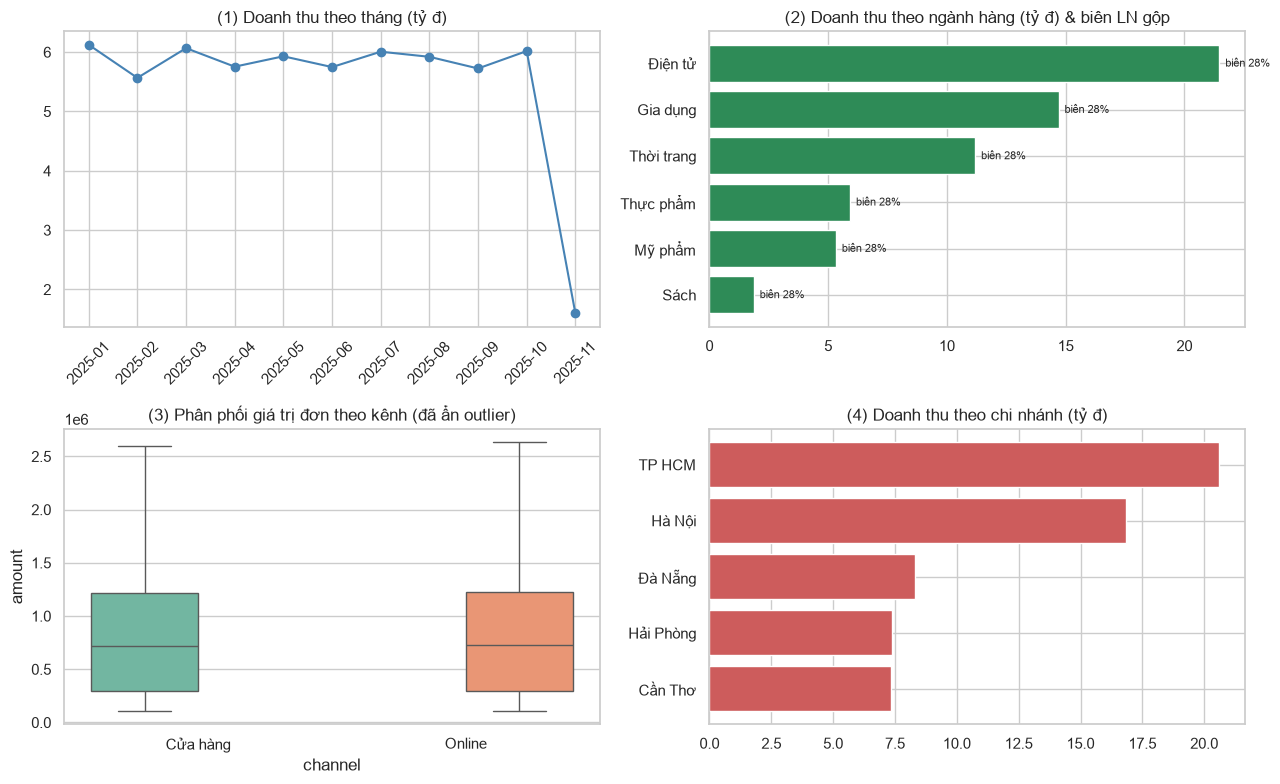

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(13, 8))

# (1) Doanh thu theo thang — xu hướng
dt_thang = tx_ht.groupby("thang")["amount"].sum() / 1e9
axes[0, 0].plot(dt_thang.index, dt_thang.values, marker="o", color="steelblue")
axes[0, 0].set_title("(1) Doanh thu theo tháng (tỷ đ)")
axes[0, 0].tick_params(axis="x", rotation=45)

# (2) Doanh thu & biên LN theo ngành hàng — cơ cấu
nganh = (tx_ht.groupby("category", observed=True)
         .agg(doanh_thu=("amount", "sum"), chi_phi=("cost", "sum")))
nganh["bien_ln"] = 1 - nganh["chi_phi"] / nganh["doanh_thu"]
nganh = nganh.sort_values("doanh_thu")
axes[0, 1].barh(nganh.index, nganh["doanh_thu"] / 1e9, color="seagreen")
for i, (dt, bl) in enumerate(zip(nganh["doanh_thu"] / 1e9, nganh["bien_ln"])):
    axes[0, 1].text(dt, i, f"  biên {bl:.0%}", va="center", fontsize=8)
axes[0, 1].set_title("(2) Doanh thu theo ngành hàng (tỷ đ) & biên LN gộp")

# (3) AOV theo kênh — hành vi
sns.boxplot(data=tx_ht, x="channel", y="amount", ax=axes[1, 0],
            showfliers=False, palette="Set2", hue="channel", legend=False)
axes[1, 0].set_title("(3) Phân phối giá trị đơn theo kênh (đã ẩn outlier)")

# (4) Doanh thu theo chi nhánh — địa lý
cn = tx_ht.groupby("branch", observed=True)["amount"].sum().sort_values() / 1e9
axes[1, 1].barh(cn.index, cn.values, color="indianred")
axes[1, 1].set_title("(4) Doanh thu theo chi nhánh (tỷ đ)")

plt.tight_layout(); plt.show()

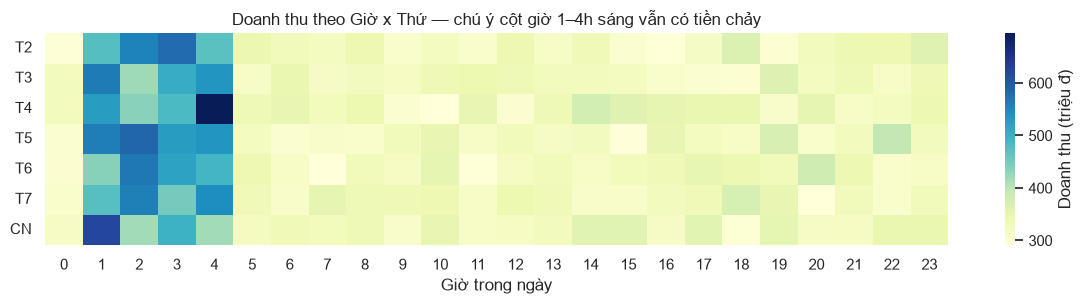

In [5]:
# Nhiệt đồ: doanh thu trung bình theo GIỜ x THỨ — nhịp sinh hoạt của khách
nhip = (tx_ht.assign(gio=tx_ht["ts"].dt.hour, thu=tx_ht["ts"].dt.dayofweek)
        .pivot_table(index="thu", columns="gio", values="amount",
                     aggfunc="sum", observed=True) / 1e6)
plt.figure(figsize=(12, 3.2))
sns.heatmap(nhip, cmap="YlGnBu", cbar_kws={"label": "Doanh thu (triệu đ)"})
plt.yticks(ticks=np.arange(7) + 0.5,
           labels=["T2", "T3", "T4", "T5", "T6", "T7", "CN"], rotation=0)
plt.title("Doanh thu theo Giờ x Thứ — chú ý cột giờ 1–4h sáng vẫn có tiền chảy")
plt.xlabel("Giờ trong ngày"); plt.ylabel("")
plt.tight_layout(); plt.show()

> **Ghi chú đọc biểu đồ:** nhiệt đồ cho thấy doanh thu tập trung giờ mở cửa (7–22h), nhưng vẫn có dòng tiền lúc **1–4h sáng** — mắt thường đã "ngửi" thấy điều bất thường. Bài 9 sẽ dùng thuật toán để chỉ đích danh các giao dịch đó.

## 8.4. Báo cáo KPI theo tháng (bảng chốt)

In [6]:
bao_cao = (tx_ht.groupby("thang")
    .agg(doanh_thu=("amount", "sum"), chi_phi=("cost", "sum"),
         so_don=("transaction_id", "size"), so_kh=("customer_id", "nunique")))
bao_cao["bien_ln_%"] = (1 - bao_cao["chi_phi"] / bao_cao["doanh_thu"]) * 100
bao_cao["aov"] = bao_cao["doanh_thu"] / bao_cao["so_don"]
bao_cao["tang_truong_%"] = bao_cao["doanh_thu"].pct_change() * 100
(bao_cao.assign(doanh_thu=bao_cao["doanh_thu"] / 1e9,
                chi_phi=bao_cao["chi_phi"] / 1e9)
 .rename(columns={"doanh_thu": "doanh_thu_ty", "chi_phi": "chi_phi_ty"})
 .round(2))

,doanh_thu_ty,chi_phi_ty,so_don,so_kh,bien_ln_%,aov,tang_truong_%
thang,,,,,,,
2025-01,6.12,4.42,5716,3313,27.85,"1,071,329.12",NaN
2025-02,5.57,4.02,5241,3201,27.82,"1,061,988.15",-9.11
2025-03,6.07,4.37,5750,3401,28.04,"1,055,096.28",9.00
2025-04,5.75,4.15,5607,3321,27.84,"1,026,334.34",-5.15
2025-05,5.93,4.27,5719,3340,27.92,"1,036,847.40",3.04
2025-06,5.75,4.14,5526,3281,28.05,"1,040,159.75",-3.07
2025-07,6.01,4.34,5777,3412,27.82,"1,039,811.00",4.51
2025-08,5.92,4.27,5677,3355,27.83,"1,042,994.86",-1.43
2025-09,5.72,4.14,5613,3367,27.76,"1,019,830.48",-3.32


---
# BÀI TẬP VỀ NHÀ

Làm trực tiếp vào các cell trống bên dưới. Nộp notebook đã chạy đầy đủ output.

#### Bài tập 1 (KPI): Xây bảng KPI theo `branch`: doanh thu, biên LN gộp, AOV, số khách hàng. Chi nhánh nào có AOV cao nhất nhưng doanh thu KHÔNG cao nhất? Vẽ biểu đồ minh họa.

In [7]:
# --- BÀI TẬP 1 ---


#### Bài tập 2 (Trực quan hóa): Vẽ biểu đồ đường doanh thu theo tháng TÁCH RIÊNG cho hai kênh Online và Cửa hàng trên cùng một trục. Kênh nào tăng trưởng ổn định hơn?

In [8]:
# --- BÀI TẬP 2 ---
